# tap.airport~ — the loops, measured

The "2/1" tape system from *Music for Airports* (`taptools/airport.h`): up to eight
free-running tape loops of unequal, incommensurate lengths, each holding one recorded phrase.
The phrases drift in and out of coincidence; the piece never repeats on a human timescale;
**no setter ever resets a phase**, because the free-run *is* the composition. Every trace
below drives the **shipping C++** through `tools/capi` via ctypes.

Sections: **1** record and return · **2** incommensurate lengths and the composite period ·
**3** the per-loop shade, measured · **4** two minutes in the terminal.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import taptools_py as tap

plt.rcParams.update({
    "figure.dpi": 96, "figure.figsize": (9, 3.2),
    "axes.grid": True, "grid.alpha": 0.3,
})
C = tap.PALETTE
sr = 48000.0

def punch(bank, loop, phrase):
    """Record a phrase onto one loop at wherever its head happens to be."""
    bank.record(loop, True)
    bank.process(phrase)
    bank.record(loop, False)

## 1 · Record and return

A click planted on a 0.5 s loop returns every 0.5 s, bit-exactly — the playback path is
bit-transparent at the default (ceiling) darken, and the loop replays the *same* imprint
every pass, so there is no generation loss to model. The head's phase advances by exactly
the samples processed, through any setter traffic. (Kernel scenarios: *"a recorded phrase
returns every loop period and no setter resets the phase"*, *"record off freezes the tape
bit-exactly"*.)

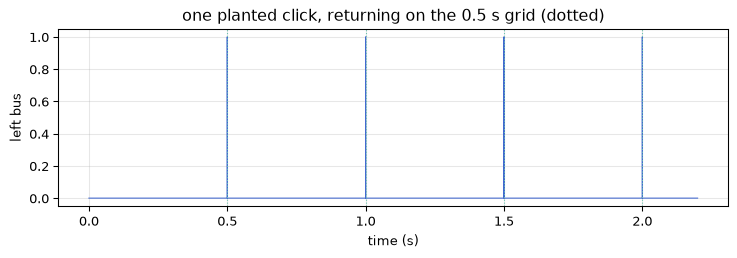

bit-exact returns at samples: [23999 47999 71999 95999] — spacing: [24000 24000 24000]
phase after the render: 0.400042 of the loop


In [2]:
b = tap.Airport(sr, 2.0, smooth_ms=0, lengths=[0.5], pans=[-1.0])
click = np.zeros(1); click[0] = 1.0
punch(b, 0, click)
yl, yr = b.process(np.zeros(int(2.2 * sr)))

t = np.arange(yl.size) / sr
fig, ax = plt.subplots(figsize=(9, 2.4))
ax.plot(t, yl, color=C[0], lw=0.8)
for k in range(1, 5):
    ax.axvline(k * 0.5 - 1 / sr, color=C[3], lw=0.8, ls=":")
ax.set_xlabel("time (s)"); ax.set_ylabel("left bus")
ax.set_title("one planted click, returning on the 0.5 s grid (dotted)")
plt.show()

returns = np.flatnonzero(yl == 1.0)
print("bit-exact returns at samples:", returns[:4], "— spacing:", np.diff(returns[:4]))
print(f"phase after the render: {b.phase(0):.6f} of the loop")

## 2 · Incommensurate lengths and the composite period

Two loops of 0.5 s and 0.625 s (24000 and 30000 samples, gcd 6000) realign only at their
lcm — 2.5 s — and the kernel's `composite_period_seconds` says exactly that. The raster
below marks every return of each loop: the coincidence pattern (bottom row) repeats at 2.5 s
and at no shorter lag. Stretch the lengths toward true incommensurability and the composite
period leaves the human timescale — that is the piece.

composite period: 2.5 s (lcm of 24000 and 30000 samples)


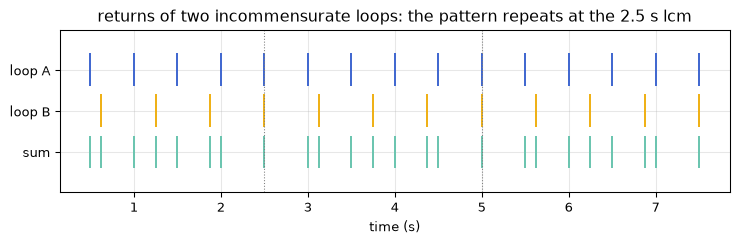

seven airport-scale loops -> composite period: inf hours


In [3]:
b = tap.Airport(sr, 2.0, smooth_ms=0, lengths=[0.5, 0.625], pans=[-1.0, 1.0])
click = np.zeros(1); click[0] = 1.0
punch(b, 0, click)
punch(b, 1, click)
print(f"composite period: {b.composite_period_seconds} s (lcm of 24000 and 30000 samples)")

yl, yr = b.process(np.zeros(int(7.5 * sr)))  # loop A on the left bus, loop B on the right
hits_a = np.flatnonzero(yl > 0.5) / sr
hits_b = np.flatnonzero(yr > 0.5) / sr
fig, ax = plt.subplots(figsize=(9, 2.2))
ax.eventplot([hits_a, hits_b, np.concatenate([hits_a, hits_b])], colors=[C[0], C[1], C[3]],
             lineoffsets=[2, 1, 0], linelengths=0.8)
for k in range(1, 3):
    ax.axvline(2.5 * k, color="gray", lw=0.8, ls=":")
ax.set_yticks([2, 1, 0], ["loop A", "loop B", "sum"])
ax.set_xlabel("time (s)")
ax.set_title("returns of two incommensurate loops: the pattern repeats at the 2.5 s lcm")
plt.show()

# The published-scale version: seven loops in the 17..31 s range, mutually coprime in samples.
b7 = tap.Airport(sr, 32.0, lengths=[17.8, 19.1, 21.3, 23.9, 26.2, 28.7, 30.9])
print(f"seven airport-scale loops -> composite period: "
      f"{b7.composite_period_seconds / 3600.0:.1f} hours")

## 3 · The per-loop shade, measured

`darken` is a playback tone per loop — not generation loss (a frozen loop replays the same
imprint forever). The same 6 kHz phrase on two loops, one shaded at 1 kHz and one left
transparent, panned to opposite buses: the level ratio between the buses lands on the
analytic one-pole transfer. (Kernel scenario: *"darken shades one loop's playback and only
that loop's"*.)

6 kHz through the 1 kHz shade: measured 0.169, predicted 0.169


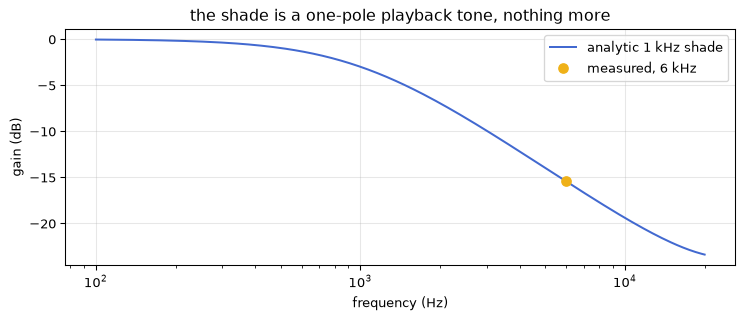

In [4]:
b = tap.Airport(sr, 2.0, smooth_ms=0, lengths=[0.5, 0.5],
                pans=[-1.0, 1.0], darkens=[1000.0, 20000.0])
tt = np.arange(int(0.5 * sr)) / sr
phrase = 0.6 * np.sin(2 * np.pi * 6000.0 * tt)
b.record(0, True); b.record(1, True)
b.process(phrase)
b.record(0, False); b.record(1, False)

yl, yr = b.process(np.zeros(int(1.0 * sr)))

def tone(x, f):
    n = np.arange(x.size)
    return 2.0 * np.abs(np.dot(x, np.exp(-2j * np.pi * f * n / sr))) / x.size

a = 1.0 - np.exp(-2 * np.pi * 1000.0 / sr)
w = 2 * np.pi * 6000.0 / sr
predicted = a / np.abs(1 - (1 - a) * np.exp(-1j * w))
measured = tone(yl, 6000.0) / tone(yr, 6000.0)
print(f"6 kHz through the 1 kHz shade: measured {measured:.3f}, predicted {predicted:.3f}")

freqs = np.geomspace(100, 20000, 200)
H = a / np.abs(1 - (1 - a) * np.exp(-1j * 2 * np.pi * freqs / sr))
fig, ax = plt.subplots()
ax.semilogx(freqs, 20 * np.log10(H), color=C[0], label="analytic 1 kHz shade")
ax.plot([6000], [20 * np.log10(measured)], "o", color=C[1], ms=7, label="measured, 6 kHz")
ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("gain (dB)")
ax.set_title("the shade is a one-pole playback tone, nothing more")
ax.legend()
plt.show()

## 4 · Two minutes in the terminal

Seven loops, lengths mutually drifting, each holding one soft chord-tone phrase (an "aah"
of a few harmonics with a slow envelope) recorded once — then the machine simply runs. Levels
and pans place the phrases across the field; two loops carry a gentle shade. Nothing in this
render repeats: the composite period of these lengths is measured above in hours.

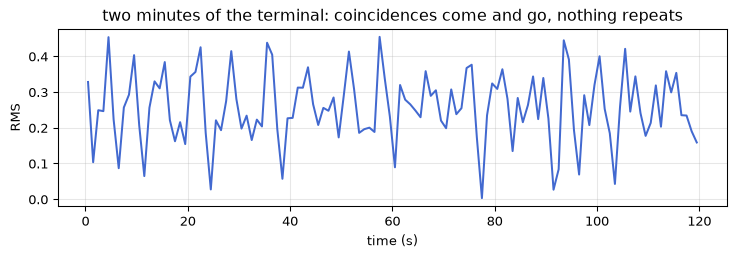

In [5]:
from IPython.display import Audio

rng = np.random.default_rng(1978)
lengths = [4.45, 4.775, 5.325, 5.975, 6.55, 7.175, 7.725]  # the "2/1" ratios, scaled down
midis   = [57, 60, 62, 64, 65, 69, 72]                     # a soft modal cluster on A
b = tap.Airport(sr, 8.0, smooth_ms=0, lengths=lengths,
                pans=[-0.8, 0.8, -0.45, 0.45, -0.15, 0.15, 0.0],
                levels=[0.5] * 7, darkens=[20000, 20000, 4000, 20000, 4000, 20000, 20000])

for i, (L, midi) in enumerate(zip(lengths, midis)):
    f = 440.0 * 2 ** ((midi - 69) / 12)
    n = int(0.55 * L * sr)  # each phrase fills about half its loop
    t = np.arange(n) / sr
    env = np.sin(np.pi * np.minimum(t / (0.4 * L), 1.0)) ** 2
    phrase = env * (0.5 * np.sin(2 * np.pi * f * t)
                    + 0.25 * np.sin(2 * np.pi * 2 * f * t + rng.uniform(0, 2 * np.pi))
                    + 0.12 * np.sin(2 * np.pi * 3 * f * t + rng.uniform(0, 2 * np.pi)))
    punch(b, i, phrase)

yl, yr = b.process(np.zeros(int(120.0 * sr)))

win = int(1.0 * sr)
frames = (yl + yr)[: (yl.size // win) * win].reshape(-1, win)
fig, ax = plt.subplots(figsize=(9, 2.4))
ax.plot(np.arange(frames.shape[0]) + 0.5, np.sqrt((frames ** 2).mean(axis=1)), color=C[0])
ax.set_xlabel("time (s)"); ax.set_ylabel("RMS")
ax.set_title("two minutes of the terminal: coincidences come and go, nothing repeats")
plt.show()

# Preview: first 30 s, embedded at 16 kHz to keep the executed notebook small (the phrases
# live below 2 kHz); tools/render writes the full-rate, full-length WAVs.
mix = np.vstack([yl[: int(30 * sr) : 3], yr[: int(30 * sr) : 3]])
Audio(np.clip(mix / max(1e-9, np.abs(mix).max()) * 0.9, -1, 1), rate=int(sr / 3))